In [1]:
import pandas as pd

df = pd.read_csv("umap_all_methods_results_with_fno_metrics.csv")

In [2]:
import re
from collections import defaultdict

columns = df.columns

groups = defaultdict(dict)

pattern = re.compile(r"(.+?)_([xyz])_(\d+d)")

for col in columns:
    m = pattern.match(col)
    if m:
        prefix, coord, dim = m.groups()
        key_str = f"{prefix}_{dim}"
        key_tuple = tuple(key_str.split("_"))
        if key_tuple not in groups:
            groups[key_tuple] = {}
        groups[key_tuple][coord] = col

# 转成 tuple 形式
result = {}
for key_tuple, coords in groups.items():
    if 'z' in coords:  # 3d
        result[key_tuple] = (coords['x'], coords['y'], coords['z'])
    else:             # 2d
        result[key_tuple] = (coords['x'], coords['y'])
        
result_2d = len({key:val for key,val in result.items() if "2d" in key})
result_3d = len({key:val for key,val in result.items() if "3d" in key})

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_all_scatter(df, result, dim_type='2d', color_col='fno_rmse'):
    """
    2x2 网格，但内容对应原 3x3 网格中的 (0,0)=1, (0,1)=2, (1,0)=4, (1,1)=5。
    即使用 keys[0], keys[1], keys[3], keys[4] 依次填充 2x2 的 1..4 号子图。
    散点点保持半透明，但 colorbar 显示完全不透明。
    """
    # 挑选 key
    keys = [k for k in result if dim_type in k]
    if not keys:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 按原 3x3 的 [1,2,4,5] 重排
    order_idx = [0, 1, 3, 4]
    ordered_keys = [keys[i] for i in order_idx if i < len(keys)]
    if not ordered_keys:
        print("❌ 可用的 keys 不足以绘制指定位置。")
        return

    shapes = ['o', '^', 's', 'D', 'x', '*', 'P', 'v']
    data_types = df['data_type'].unique()
    shape_map = {dt: shapes[i % len(shapes)] for i, dt in enumerate(data_types)}

    # 2x2 网格
    nrows, ncols = 2, 2
    fig = plt.figure(figsize=(ncols*6.4, nrows*6))

    last_ax = None
    for idx, key in enumerate(ordered_keys, start=1):  # 子图编号 1..4
        cols = result[key]
        dim = len(cols)

        ax = fig.add_subplot(nrows, ncols, idx, projection='3d' if dim == 3 else None)
        last_ax = ax

        for dt in data_types:
            sub_df = df[df['data_type'] == dt]
            if dim == 2:
                ax.scatter(
                    sub_df[cols[0]], sub_df[cols[1]],
                    c=sub_df[color_col], cmap='viridis',
                    marker=shape_map[dt], label=dt, alpha=0.01, s=40
                )
            else:
                ax.scatter(
                    sub_df[cols[0]], sub_df[cols[1]], sub_df[cols[2]],
                    c=sub_df[color_col], cmap='viridis',
                    marker=shape_map[dt], label=dt, alpha=0.01, s=40
                )

        ax.set_xlabel(cols[0])
        ax.set_ylabel(cols[1])
        if dim == 3:
            ax.set_zlabel(cols[2])
        ax.set_title(f"{'_'.join(key)}", fontsize=10)

    # === 独立 colorbar（不透明） ===
    norm = mcolors.Normalize(vmin=df[color_col].min(), vmax=df[color_col].max())
    sm = cm.ScalarMappable(cmap='viridis', norm=norm)
    sm.set_array([])  # 必须给个 dummy array
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = plt.colorbar(sm, cax=cbar_ax)
    cbar.set_label(color_col)

    # 图例（去重）
    if last_ax is not None:
        handles, labels = last_ax.get_legend_handles_labels()
        uniq = dict(zip(labels, handles))
        fig.legend(list(uniq.values()), list(uniq.keys()),
                   loc='upper right', title='data_type')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()





/tmp/ipykernel_2500545/2789816506.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


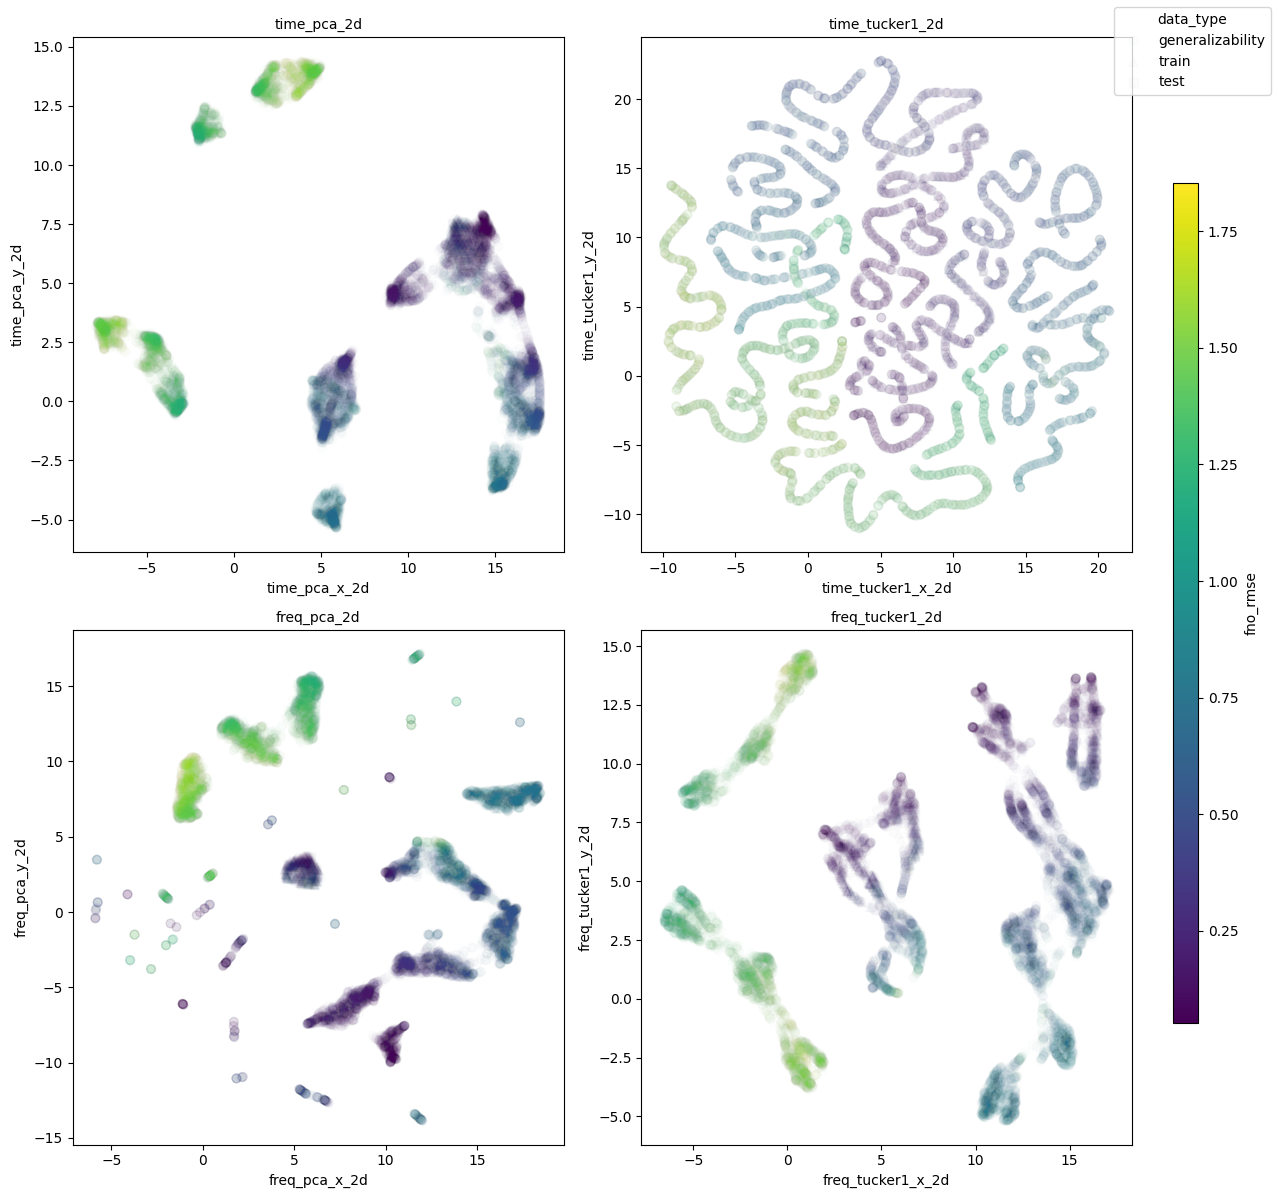

In [43]:
plot_all_scatter(df, result, dim_type='2d', color_col='fno_rmse')

/tmp/ipykernel_2813481/2789816506.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


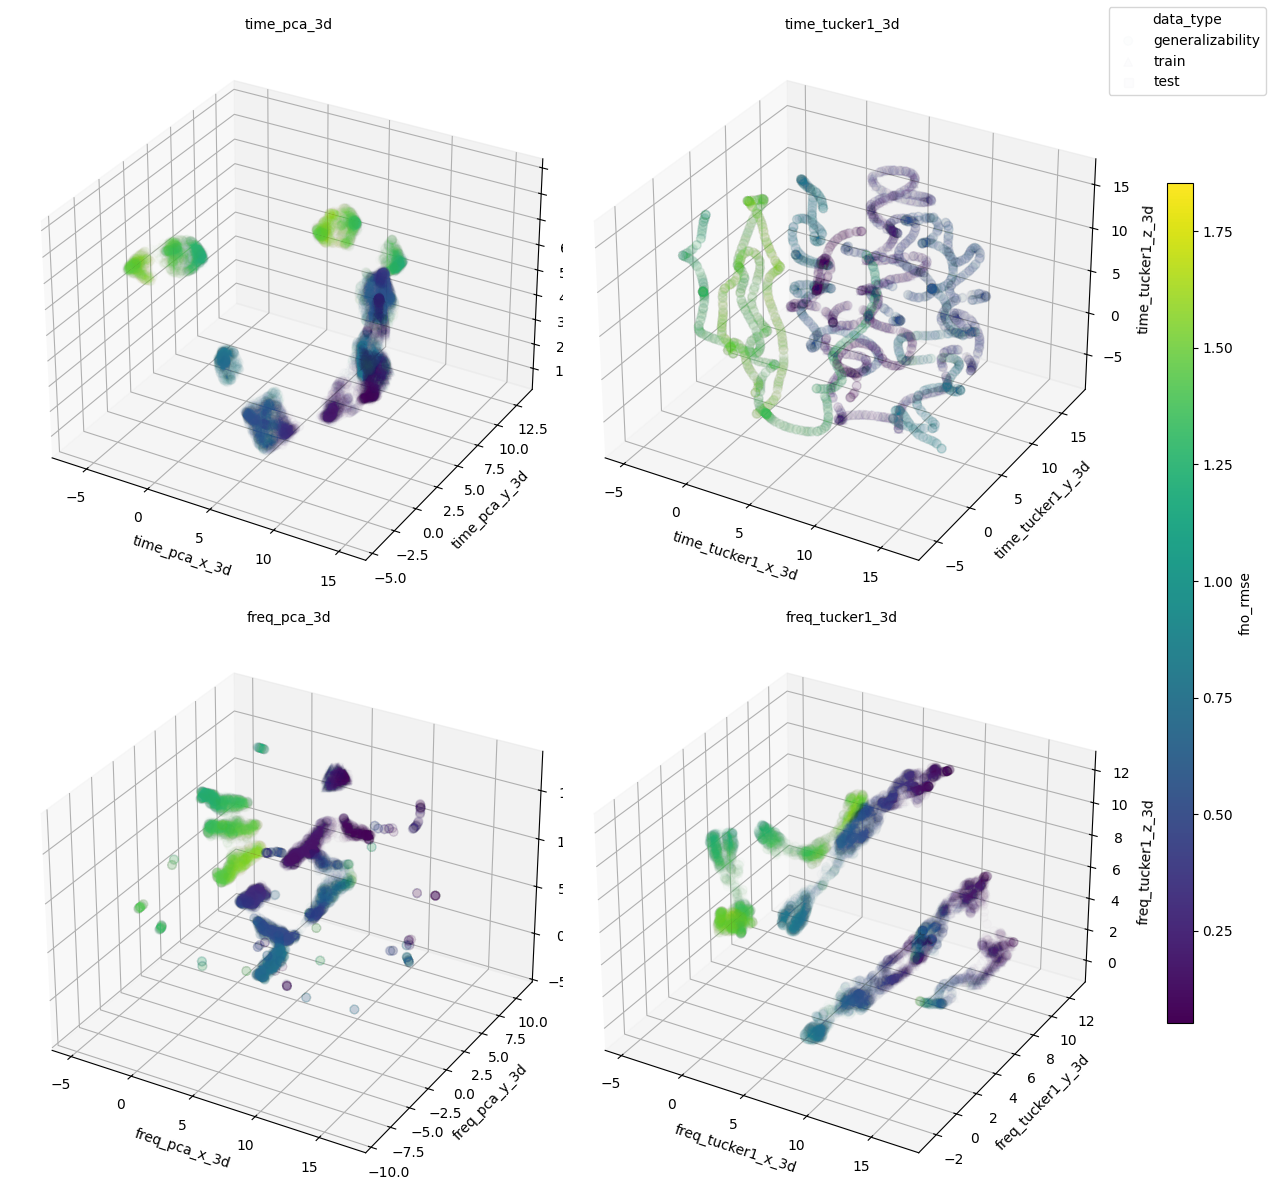

In [5]:
plot_all_scatter(df, result, dim_type='3d', color_col='fno_rmse')

In [6]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.lines import Line2D
import pandas as pd

def plot_all_scatter_by_data_type(df, result, dim_type='2d', max_per_fig=9, point_size=40):
    """
    2x2 网格，但内容对应原 3x3 网格中的 (0,0)=1, (0,1)=2, (1,0)=4, (1,1)=5。
    即从首个“9宫格页”里按索引 [0,1,3,4] 选出 4 个子图，放入 2x2。
    颜色按 data_type 分类；
    generalizability / train / test 使用不同透明度。
    """
    # 1) 选 key，并取“首个9宫格页”的前 9 个
    keys_all = [k for k in result if dim_type in k]
    if not keys_all:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return
    first_page = keys_all[:9]

    # 2) 取与原 3x3 的 (1,2,4,5) 对应的索引 [0,1,3,4]
    order_idx = [0, 1, 3, 4]
    keys = [first_page[i] for i in order_idx if i < len(first_page)]
    if not keys:
        print("❌ 可用的 keys 不足以绘制指定位置。")
        return

    # 3) data_type -> 颜色
    data_types = df['data_type'].unique()
    cmap = plt.cm.get_cmap('tab10', len(data_types))
    color_map = {dt: cmap(i) for i, dt in enumerate(data_types)}

    # ✅ 为每个 data_type 指定不同透明度
    alpha_map = {
        'generalizability': 0.005,
        'train': 0.01,
        'test': 0.1,
    }

    # 4) 固定 2x2 网格
    nrows, ncols = 2, 2
    fig = plt.figure(figsize=(ncols*6.4, nrows*6))

    sc = None
    last_ax = None
    for idx, key in enumerate(keys, start=1):  # 子图编号 1..4
        cols = result[key]
        dim = len(cols)

        ax = fig.add_subplot(nrows, ncols, idx, projection='3d' if dim == 3 else None)
        last_ax = ax

        # 按 data_type 分类上色 + 动态透明度
        for dt in data_types:
            sub = df[df['data_type'] == dt]
            if sub.empty:
                continue

            alpha_val = alpha_map.get(str(dt).lower(), 0.01)  # 默认 0.01

            if dim == 2:
                sc = ax.scatter(
                    sub[cols[0]], sub[cols[1]],
                    color=color_map[dt], label=dt, alpha=alpha_val, s=point_size
                )
            else:
                sc = ax.scatter(
                    sub[cols[0]], sub[cols[1]], sub[cols[2]],
                    color=color_map[dt], label=dt, alpha=alpha_val, s=point_size
                )

        ax.set_xlabel(cols[0])
        ax.set_ylabel(cols[1])
        if dim == 3:
            ax.set_zlabel(cols[2])
        ax.set_title(f"{'_'.join(key)}", fontsize=10)

    # 5) 全局图例
    handles = [Line2D([0],[0], marker='o', linestyle='', color=color_map[dt], label=dt, markersize=8)
               for dt in data_types]
    fig.legend(handles, [h.get_label() for h in handles], loc='upper right', title='data_type')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()




/tmp/ipykernel_2500545/2029680143.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(data_types))


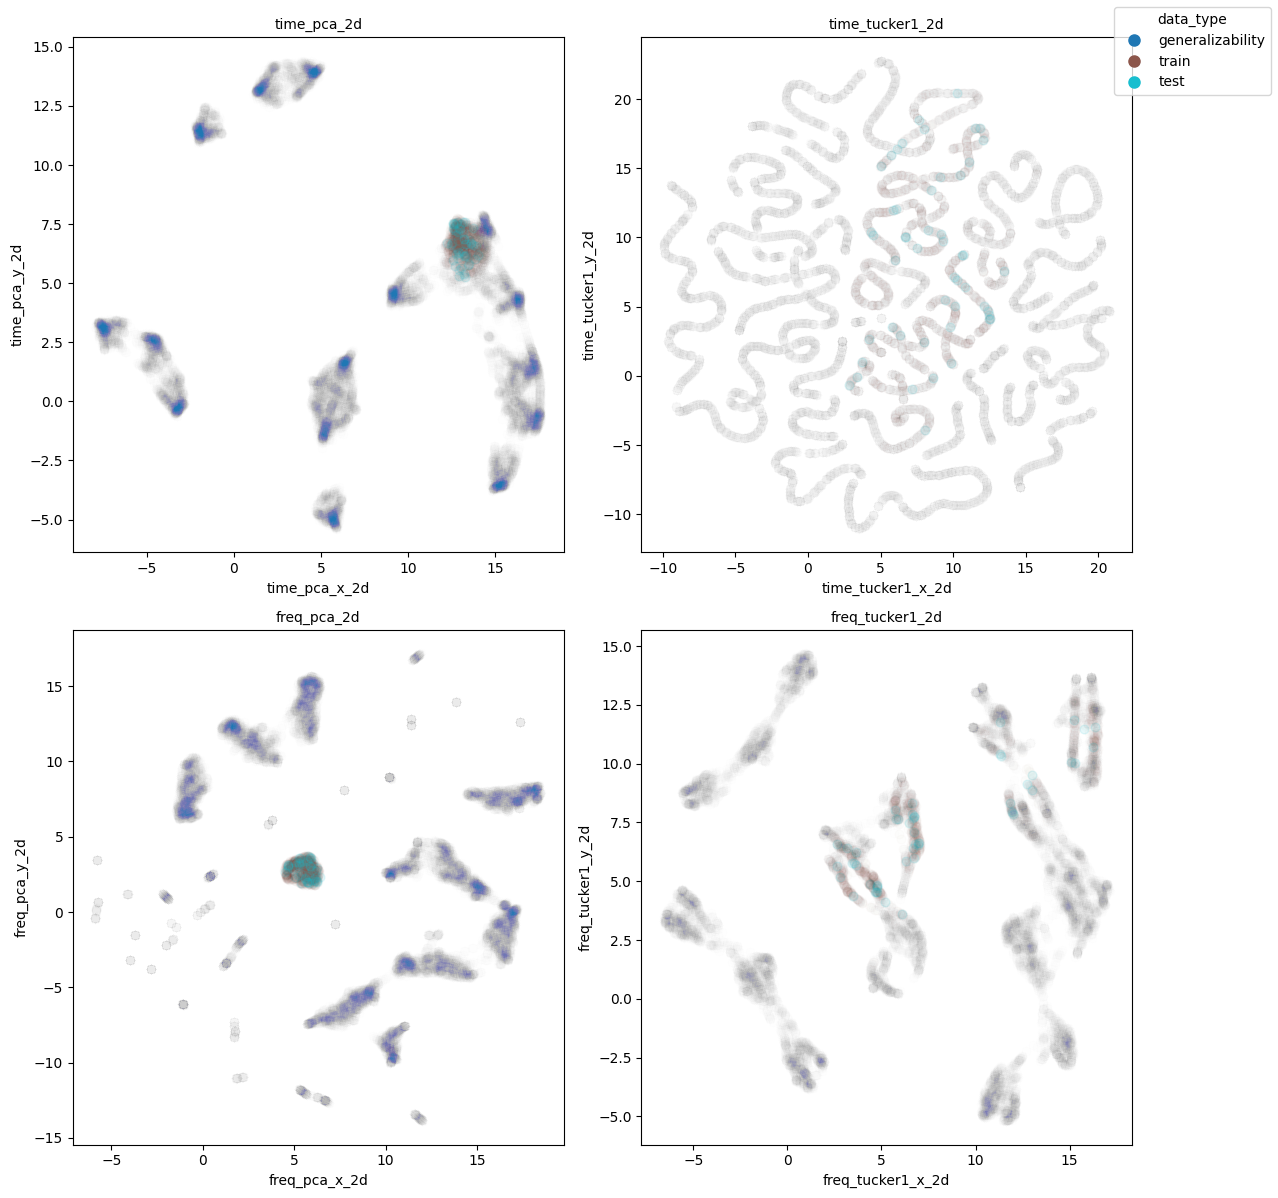

In [41]:
plot_all_scatter_by_data_type(df, result, dim_type='2d', max_per_fig=9, point_size=40)

/tmp/ipykernel_2813481/2029680143.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(data_types))


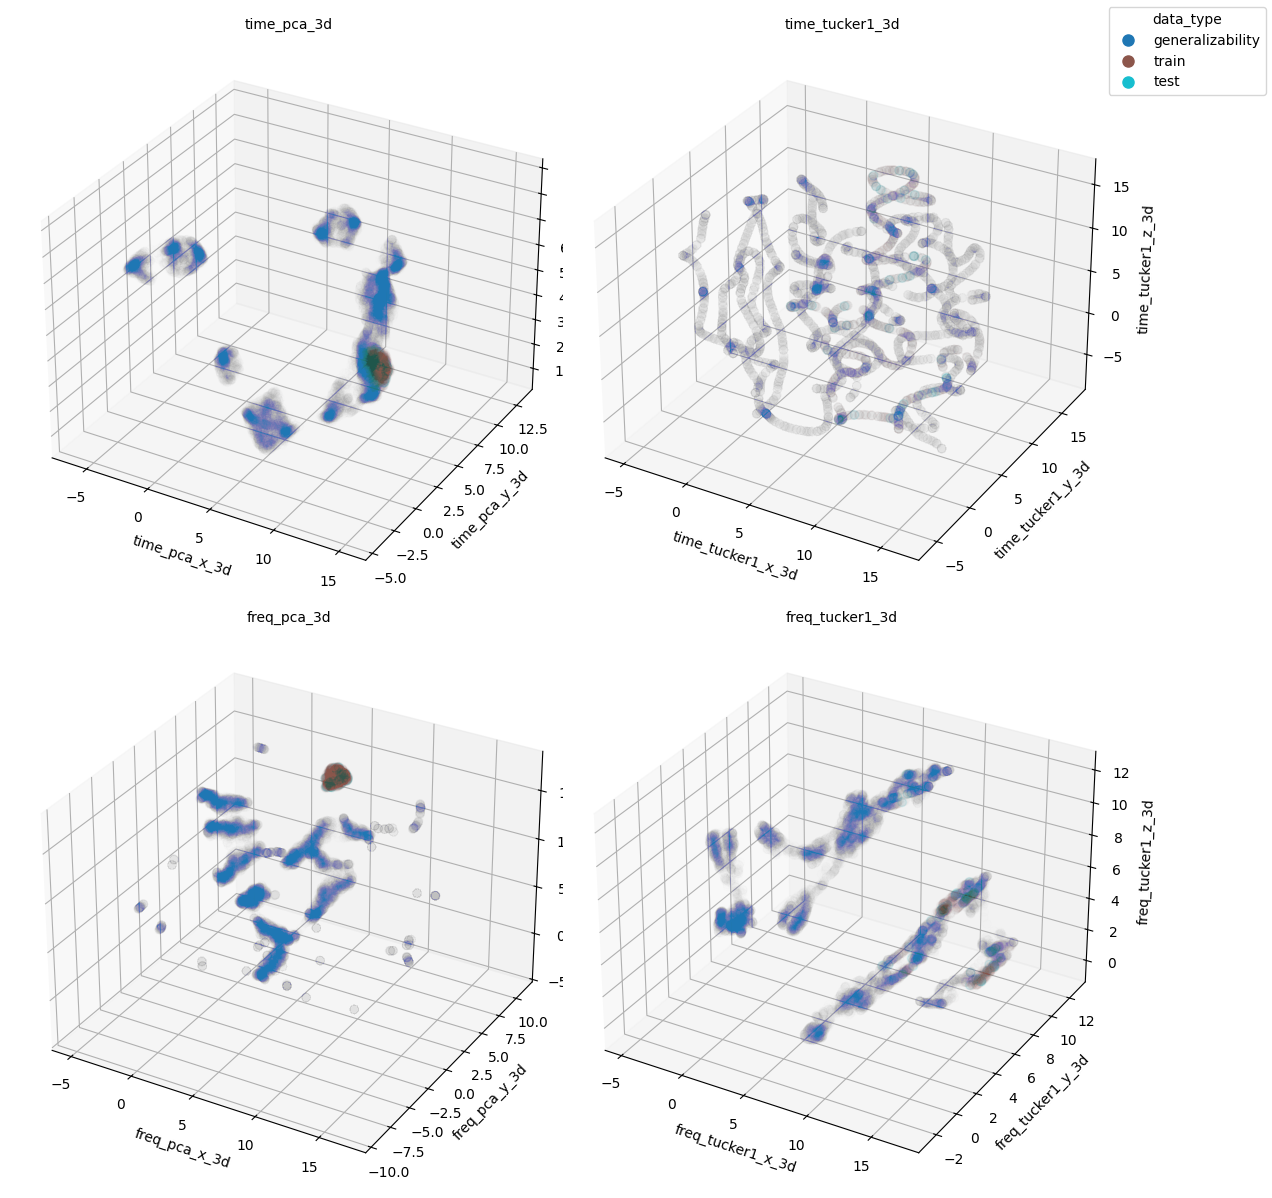

In [7]:
plot_all_scatter_by_data_type(df, result, dim_type='3d', max_per_fig=9, point_size=40)

In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  # ← 用于构造不透明的图例句柄

def plot_all_scatter_by_vrange(df, result, dim_type='2d', point_size=40):
    """
    2x2 网格，但内容对应原 3x3 网格中的 (0,0)=1, (0,1)=2, (1,0)=4, (1,1)=5。
    即使用 keys[0], keys[1], keys[3], keys[4] 依次填充 2x2 的 1..4 号子图。
    """
    # 挑选 key
    keys_all = [k for k in result if dim_type in k]
    if not keys_all:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 关键：按原 3x3 的 [1,2,4,5] 位置重排
    order_idx = [0, 1, 3, 4]
    keys = [keys_all[i] for i in order_idx if i < len(keys_all)]
    if not keys:
        print("❌ 可用的 keys 不足以绘制指定位置。")
        return

    # 只筛选 data_type='generalizability' 的数据
    df_sub = df[df['data_type'] == 'generalizability'].copy()
    if df_sub.empty:
        print("❌ 没有找到 data_type='generalizability' 的数据行。")
        return

    # 解析 grf_config -> vrange
    import ast
    def parse_vrange(s):
        d = ast.literal_eval(s)
        return (d.get('vmax'), d.get('vmin'))

    df_sub['vrange'] = df_sub['grf_config'].map(parse_vrange)

    vranges = sorted(df_sub['vrange'].unique())
    cmap = plt.cm.get_cmap('tab20', len(vranges))
    vrange_color_map = {vr: cmap(i) for i, vr in enumerate(vranges)}

    # 固定 2x2 网格
    nrows, ncols = 2, 2
    fig = plt.figure(figsize=(ncols*6.4, nrows*6))

    for idx, key in enumerate(keys, start=1):  # 子图编号 1..4
        cols = result[key]
        dim = len(cols)

        ax = fig.add_subplot(nrows, ncols, idx, projection='3d' if dim == 3 else None)

        # 按 vrange 分类画点（点保持半透明）
        for vr in vranges:
            sub_df_vr = df_sub[df_sub['vrange'] == vr]
            if dim == 2:
                ax.scatter(
                    sub_df_vr[cols[0]], sub_df_vr[cols[1]],
                    color=vrange_color_map[vr],
                    label=f'vmax={vr[0]}, vmin={vr[1]}',
                    alpha=0.007, s=point_size
                )
            else:
                ax.scatter(
                    sub_df_vr[cols[0]], sub_df_vr[cols[1]], sub_df_vr[cols[2]],
                    color=vrange_color_map[vr],
                    label=f'vmax={vr[0]}, vmin={vr[1]}',
                    alpha=0.007, s=point_size
                )

        ax.set_xlabel(cols[0])
        ax.set_ylabel(cols[1])
        if dim == 3:
            ax.set_zlabel(cols[2])

        ax.set_title(f"{'_'.join(key)}", fontsize=10)

    # === 不透明图例（用代理句柄构造） ===
    legend_labels = [f'vmax={vr[0]}, vmin={vr[1]}' for vr in vranges]
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=vrange_color_map[vr],
               markeredgecolor=vrange_color_map[vr],
               markersize=8, alpha=1.0, label=lbl)
        for vr, lbl in zip(vranges, legend_labels)
    ]
    fig.legend(legend_handles, legend_labels, loc='upper right', title='(vmax, vmin)')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()



/tmp/ipykernel_2754836/967475165.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(vranges))


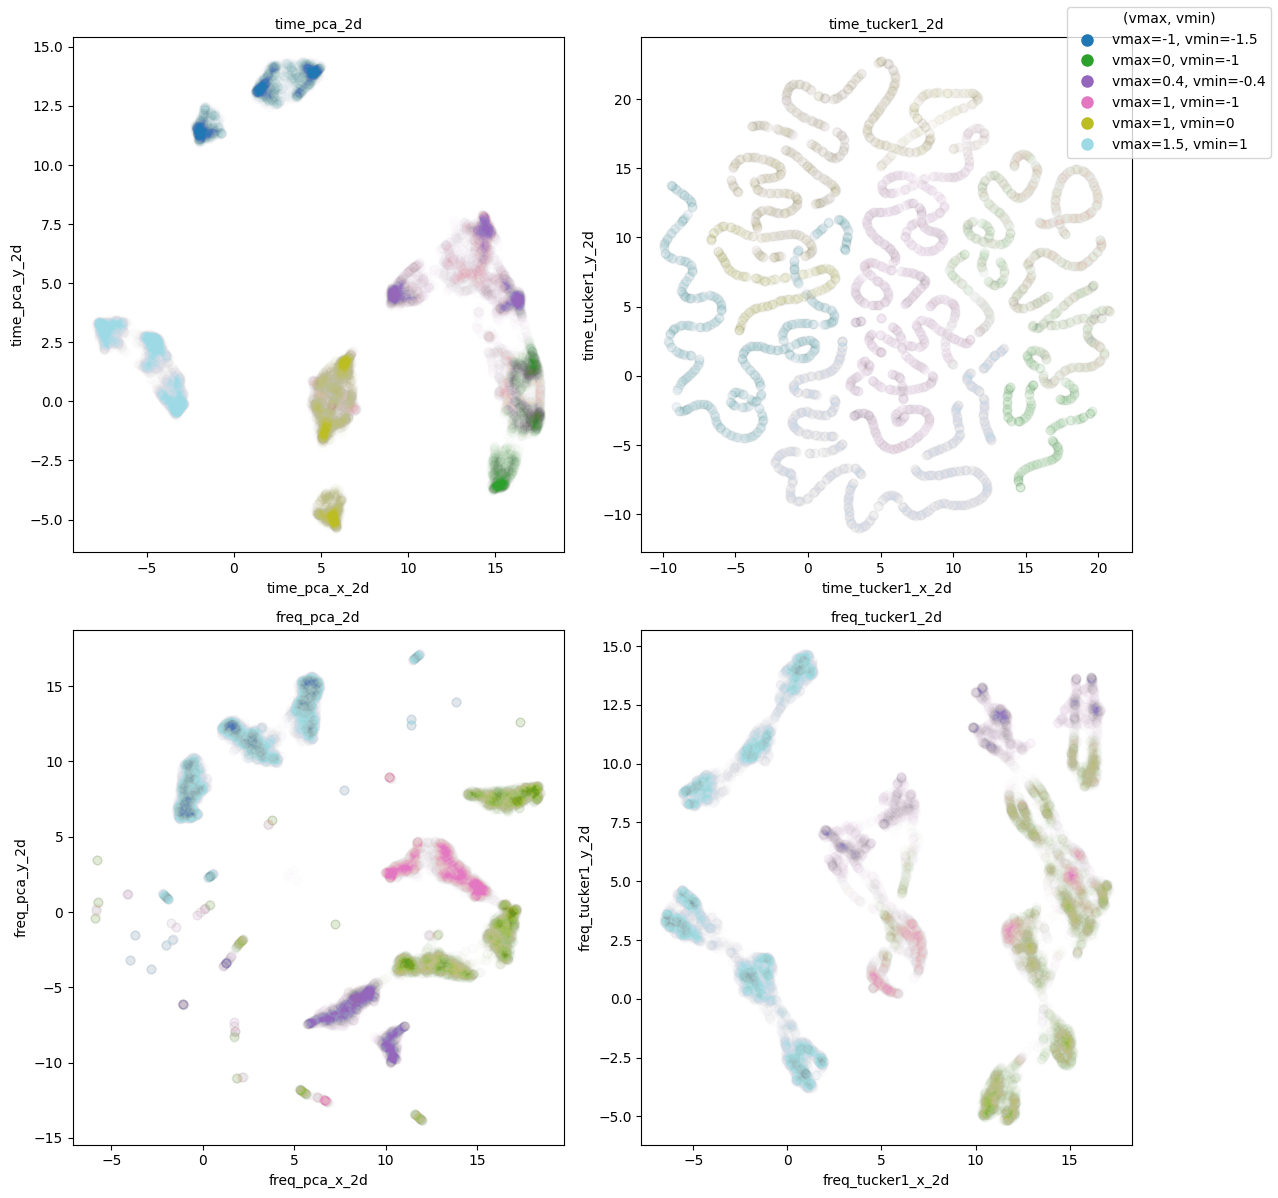

In [6]:
plot_all_scatter_by_vrange(df, result, dim_type='2d', point_size=40)

/tmp/ipykernel_2813481/967475165.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(vranges))


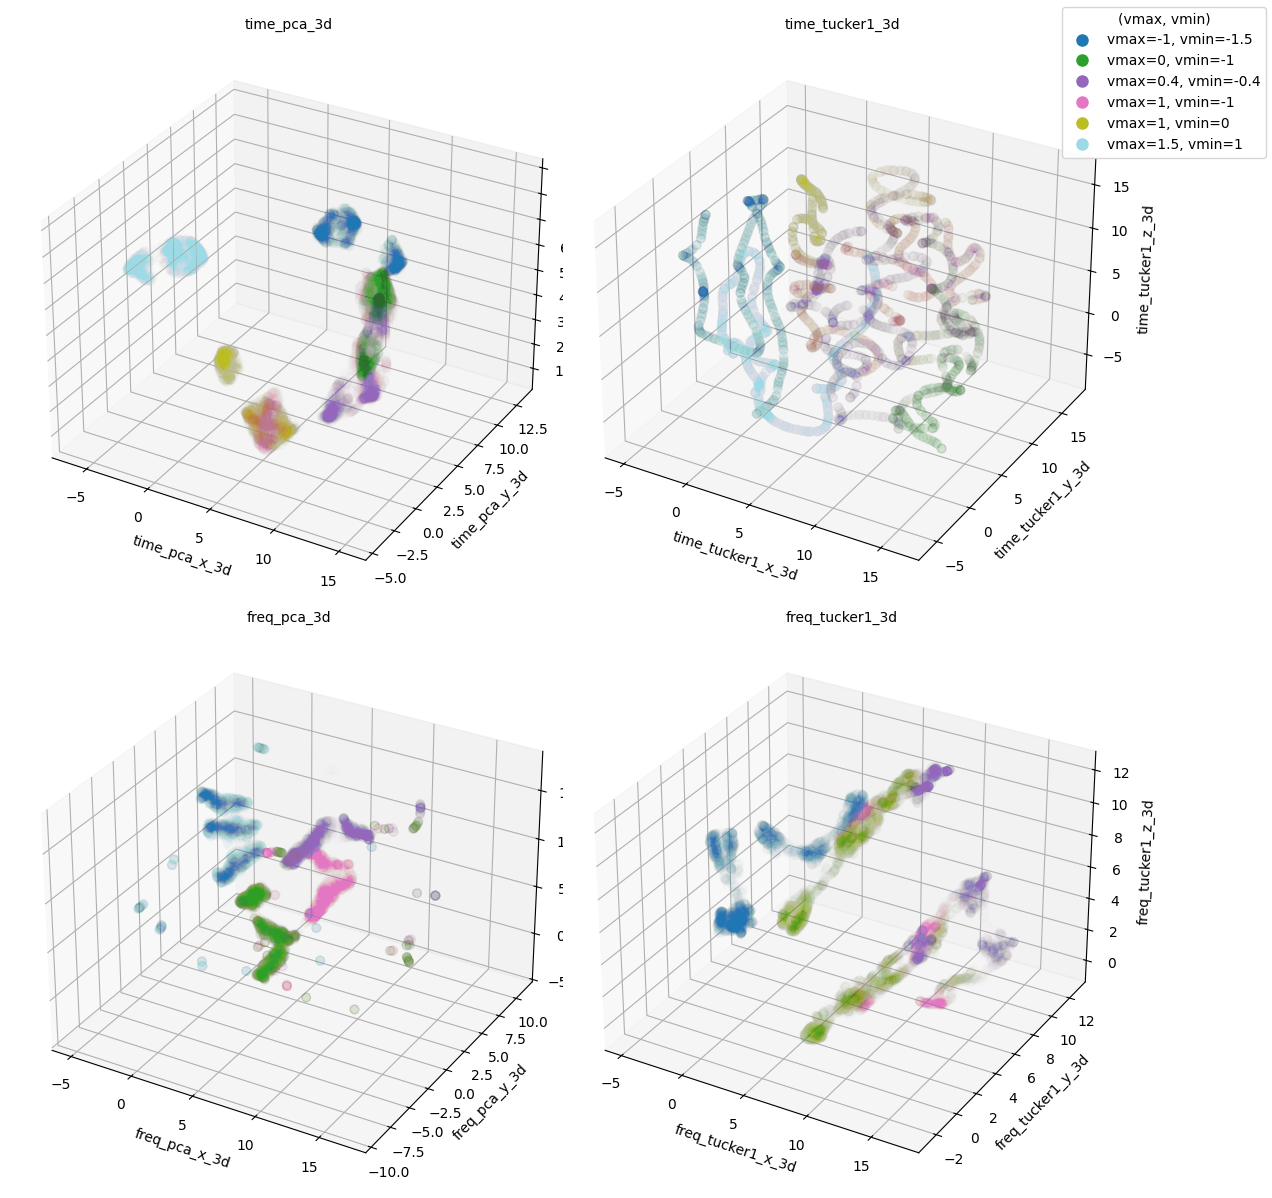

In [9]:
plot_all_scatter_by_vrange(df, result, dim_type='3d', point_size=40)

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ast

def plot_all_scatter_by_kernel(df, result, dim_type='2d', point_size=40):
    """
    2x2 网格，但内容对应原 3x3 网格中的 (0,0)=1, (0,1)=2, (1,0)=4, (1,1)=5。
    即使用 keys[0], keys[1], keys[3], keys[4] 依次填充 2x2 的 1..4 号子图。
    颜色根据 grf_config 的 kernel 类型分类；散点 alpha 半透明，图例不透明。
    """
    # 挑选 key
    keys_all = [k for k in result if dim_type in k]
    if not keys_all:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 关键：按原 3x3 的 [1,2,4,5] 重排
    order_idx = [0, 1, 3, 4]
    keys = [keys_all[i] for i in order_idx if i < len(keys_all)]
    if not keys:
        print("❌ 可用的 keys 不足以绘制指定位置。")
        return

    # 只筛选 data_type='generalizability' 的数据
    df_sub = df[df['data_type'] == 'generalizability'].copy()
    if df_sub.empty:
        print("❌ 没有找到 data_type='generalizability' 的数据行。")
        return

    # 解析 grf_config -> kernel
    def parse_kernel(s):
        d = ast.literal_eval(s)
        return d.get('kernel', 'unknown')

    df_sub['kernel'] = df_sub['grf_config'].map(parse_kernel)

    kernels = sorted(df_sub['kernel'].unique())
    cmap = plt.cm.get_cmap('tab10', len(kernels))
    kernel_color_map = {k: cmap(i) for i, k in enumerate(kernels)}

    # 固定 2x2 网格
    nrows, ncols = 2, 2
    fig = plt.figure(figsize=(ncols*6.4, nrows*6))

    for idx, key in enumerate(keys, start=1):  # 子图编号 1..4
        cols = result[key]
        dim = len(cols)

        ax = fig.add_subplot(nrows, ncols, idx, projection='3d' if dim == 3 else None)

        # 按 kernel 分类画点（点半透明）
        for k in kernels:
            sub_df_k = df_sub[df_sub['kernel'] == k]
            if dim == 2:
                ax.scatter(
                    sub_df_k[cols[0]], sub_df_k[cols[1]],
                    color=kernel_color_map[k],
                    label=f'kernel={k}',
                    alpha=0.01, s=point_size
                )
            else:
                ax.scatter(
                    sub_df_k[cols[0]], sub_df_k[cols[1]], sub_df_k[cols[2]],
                    color=kernel_color_map[k],
                    label=f'kernel={k}',
                    alpha=0.01, s=point_size
                )

        ax.set_xlabel(cols[0])
        ax.set_ylabel(cols[1])
        if dim == 3:
            ax.set_zlabel(cols[2])
        ax.set_title(f"{'_'.join(key)}", fontsize=10)

    # === 不透明图例（代理句柄） ===
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=kernel_color_map[k],
               markeredgecolor=kernel_color_map[k],
               markersize=8, alpha=1.0, label=f'kernel={k}')
        for k in kernels
    ]
    fig.legend(legend_handles, [h.get_label() for h in legend_handles],
               loc='upper right', title='Kernel Type')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


/tmp/ipykernel_2754836/4061517713.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(kernels))


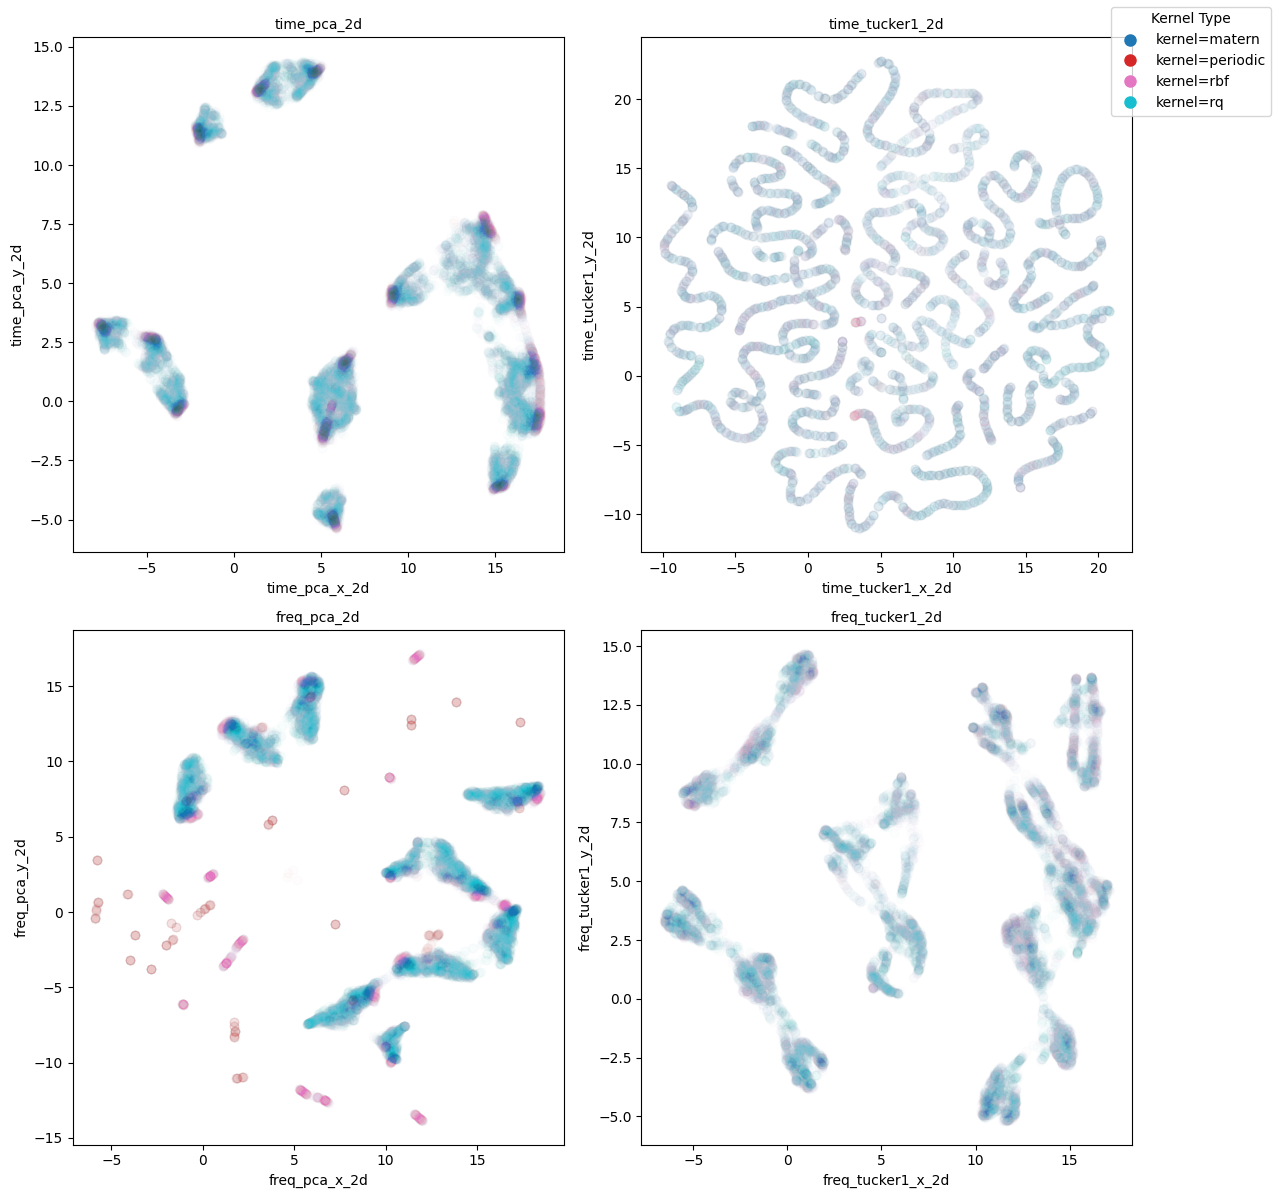

In [13]:
plot_all_scatter_by_kernel(df, result, dim_type='2d', point_size=40)

/tmp/ipykernel_2813481/4061517713.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(kernels))


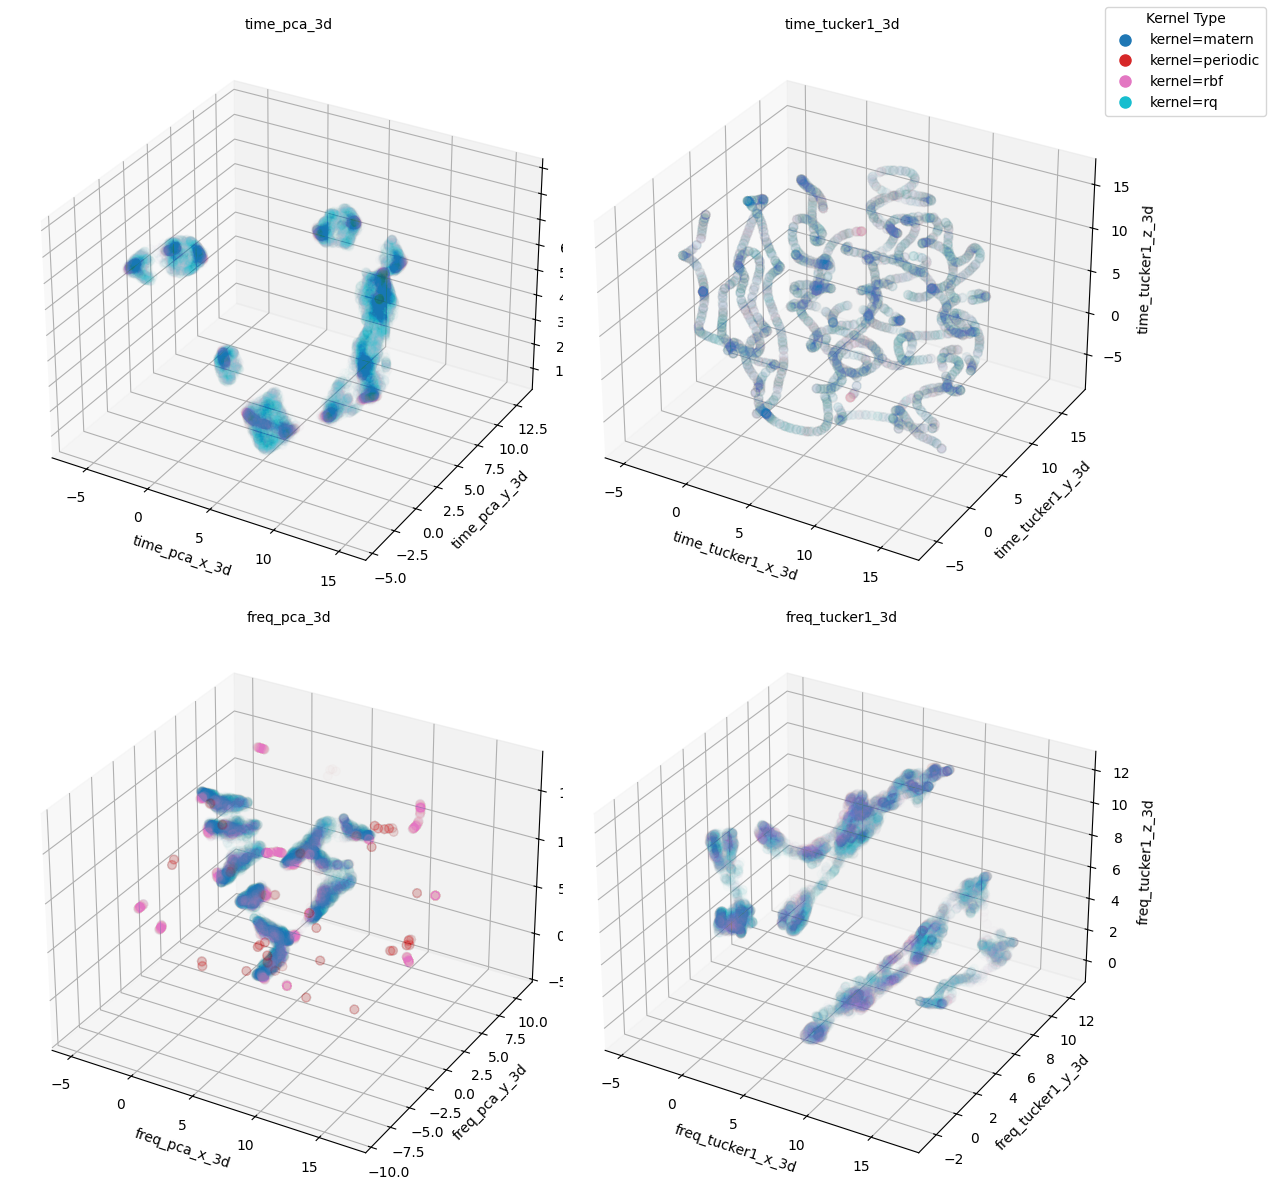

In [11]:
plot_all_scatter_by_kernel(df, result, dim_type='3d', point_size=40)

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import ast

def plot_all_scatter_by_grftype(df, result, dim_type='2d', point_size=40):
    """
    2x2 网格，但内容对应原 3x3 网格中的 (0,0)=1, (0,1)=2, (1,0)=4, (1,1)=5。
    即使用 keys[0], keys[1], keys[3], keys[4] 依次填充 2x2 的 1..4 号子图。
    颜色根据 grf_config['grf_type'] 分类；散点半透明，图例不透明。
    """
    # 选 key
    keys_all = [k for k in result if dim_type in k]
    if not keys_all:
        print(f"❌ 没有找到任何 {dim_type} 的key。")
        return

    # 对应原 3x3 的 [1,2,4,5]
    order_idx = [0, 1, 3, 4]
    keys = [keys_all[i] for i in order_idx if i < len(keys_all)]
    if not keys:
        print("❌ 可用的 keys 不足以绘制指定位置。")
        return

    # 只取 generalizability
    df_sub = df[df['data_type'] == 'generalizability'].copy()
    if df_sub.empty:
        print("❌ 没有找到 data_type='generalizability' 的数据行。")
        return

    # 解析 grf_config -> grf_type
    def parse_grftype(s):
        d = ast.literal_eval(s)
        return d.get('grf_type', 'unknown')

    df_sub['grf_type'] = df_sub['grf_config'].map(parse_grftype)

    grf_types = sorted(df_sub['grf_type'].unique())
    cmap = plt.cm.get_cmap('tab10', len(grf_types))
    grf_type_color_map = {gt: cmap(i) for i, gt in enumerate(grf_types)}

    # 2x2 网格
    nrows, ncols = 2, 2
    fig = plt.figure(figsize=(ncols*6.4, nrows*6))

    for idx, key in enumerate(keys, start=1):  # 子图编号 1..4
        cols = result[key]
        dim = len(cols)

        ax = fig.add_subplot(nrows, ncols, idx, projection='3d' if dim == 3 else None)

        # 按 grf_type 分类画点（点半透明）
        for gt in grf_types:
            sub_df_gt = df_sub[df_sub['grf_type'] == gt]
            if sub_df_gt.empty:
                continue
            if dim == 2:
                ax.scatter(
                    sub_df_gt[cols[0]], sub_df_gt[cols[1]],
                    color=grf_type_color_map[gt],
                    label=f'grf_type={gt}',
                    alpha=0.007, s=point_size
                )
            else:
                ax.scatter(
                    sub_df_gt[cols[0]], sub_df_gt[cols[1]], sub_df_gt[cols[2]],
                    color=grf_type_color_map[gt],
                    label=f'grf_type={gt}',
                    alpha=0.007, s=point_size
                )

        ax.set_xlabel(cols[0])
        ax.set_ylabel(cols[1])
        if dim == 3:
            ax.set_zlabel(cols[2])
        ax.set_title(f"{'_'.join(key)}", fontsize=10)

    # 不透明图例（代理句柄）
    legend_handles = [
        Line2D([0], [0], marker='o', linestyle='',
               markerfacecolor=grf_type_color_map[gt],
               markeredgecolor=grf_type_color_map[gt],
               markersize=8, alpha=1.0, label=f'grf_type={gt}')
        for gt in grf_types
    ]
    fig.legend(legend_handles, [h.get_label() for h in legend_handles],
               loc='upper right', title='GRF Type')

    plt.tight_layout(rect=[0, 0, 0.9, 1])
    plt.show()


/tmp/ipykernel_2754836/4059369987.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(grf_types))


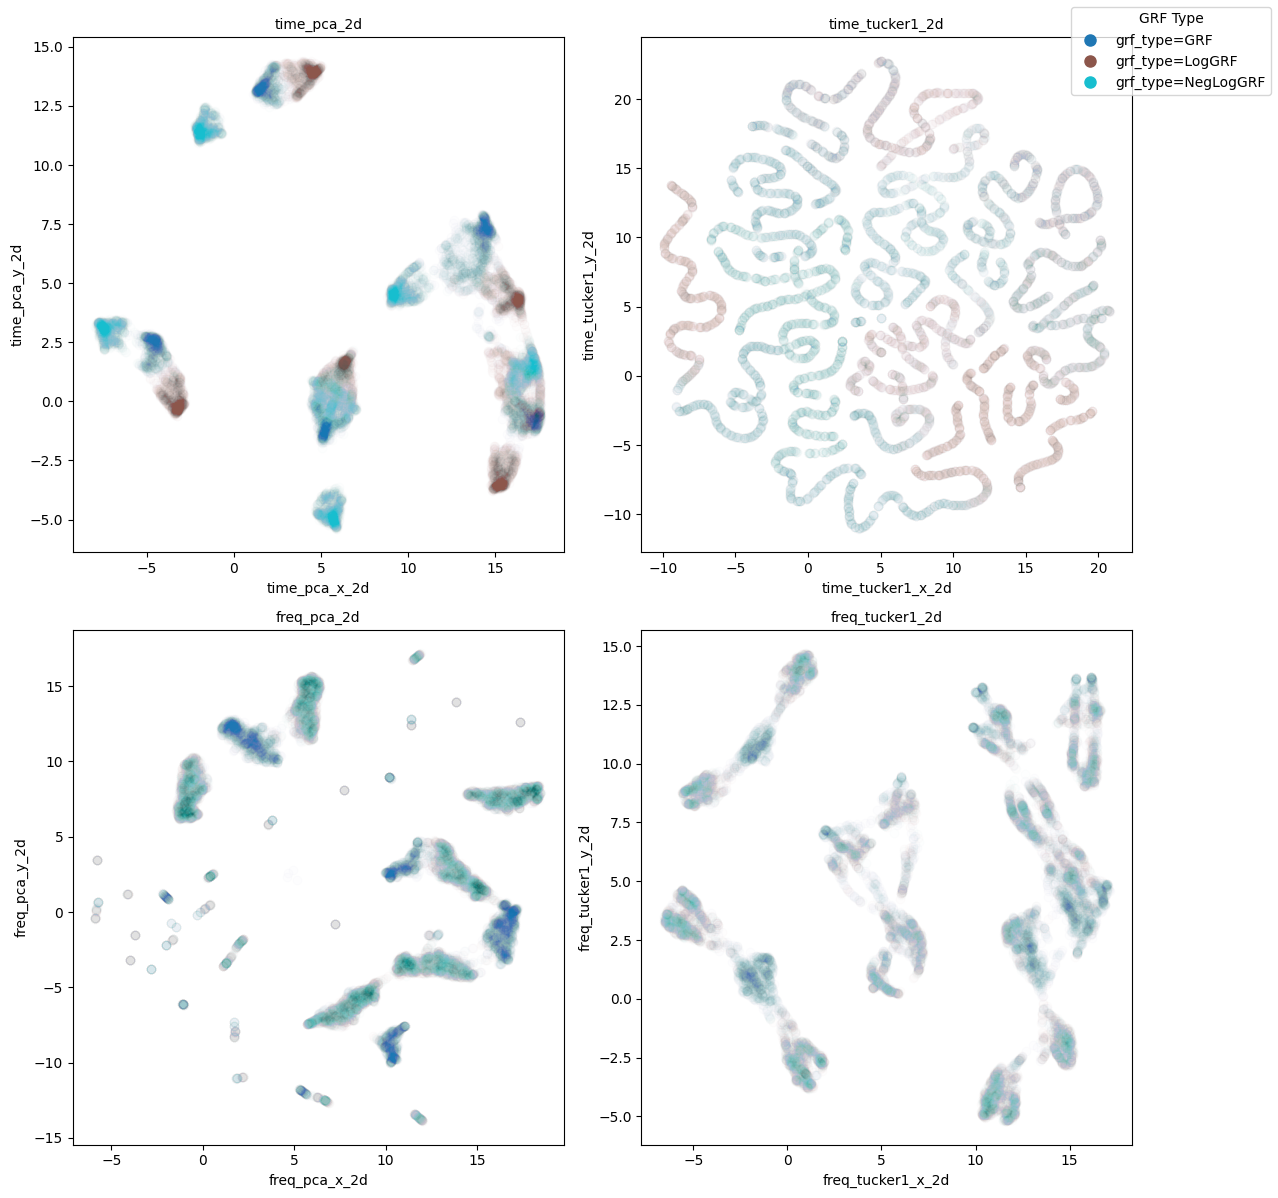

In [23]:
plot_all_scatter_by_grftype(df, result, dim_type='2d', point_size=40)

/tmp/ipykernel_2813481/4059369987.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(grf_types))


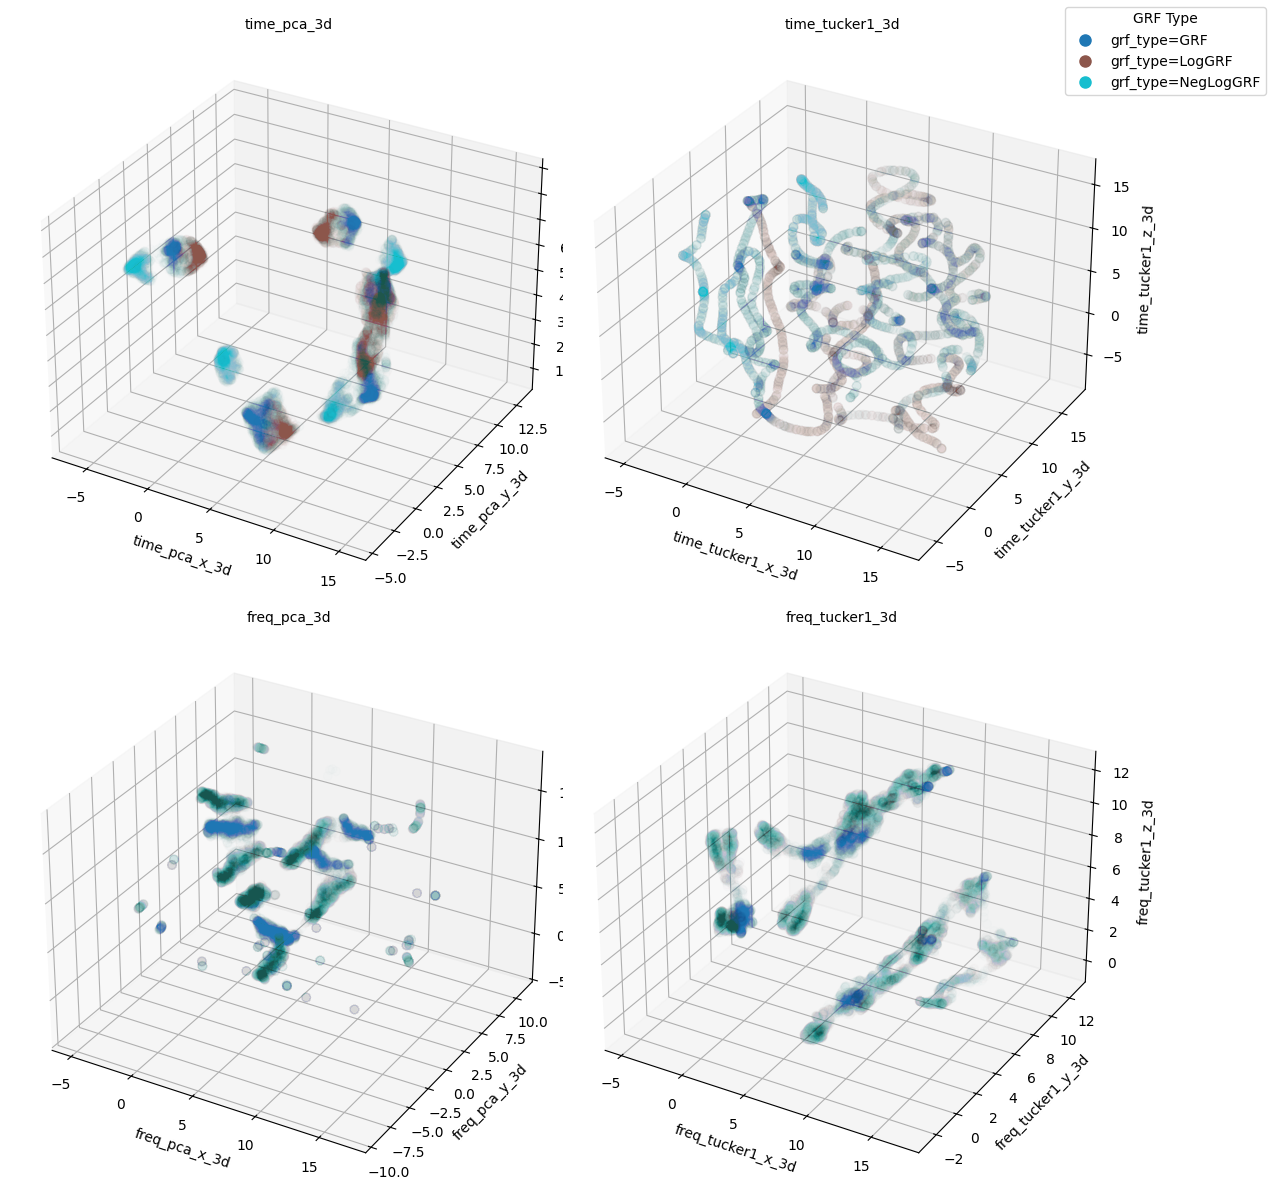

In [13]:
plot_all_scatter_by_grftype(df, result, dim_type='3d', point_size=40)